
#1. Convolution Operation (5 marks)
Implement a Python function conv2d() that performs 2D convolution between the
grayscale image provided and a kernel.
(a) Use the function to convolve the image with the following 3 × 3 kernels. Clip
the output vakues between 0 ans 255 and display them:
(i)


−1 0 1
−2 0 2
−1 0 1

 (ii)


−1 −2 −1
0 0 0
1 2 1


(b) Modify the above function to implement max-pooling on the same image and
display the result.

In [31]:
import numpy as np
def convolution2d(image, kernel, bias):
    m, n = kernel.shape
    if (m == n):
        y, x = image.shape
        y = y - m + 1
        x = x - m + 1
        new_image = np.zeros((y,x))
        for i in range(y):
            for j in range(x):
                new_image[i][j] = (np.sum(image[i:i+m, j:j+m]*kernel) )%255
    return new_image

In [34]:

# Import the necessary libraries
from PIL import Image
from numpy import asarray
import matplotlib.pyplot as plt



# load the image and convert into
# numpy array
img = Image.open('/content/sample_image.png')
image = asarray(img)


kernel1= np.matrix([[-1,0,1],[-2,0,2],[-1,0,1]])
kernel2= np.matrix([[-1,-2,-1],[0,0,0],[1,2,1]])

In [35]:
data1=convolution2d(image,kernel1,0)
data2=convolution2d(image,kernel2,0)


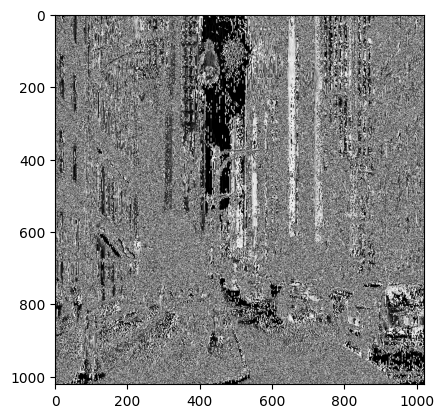

In [36]:

plt.imshow(data1,cmap='gray')
plt.imshow(data2,cmap='gray')

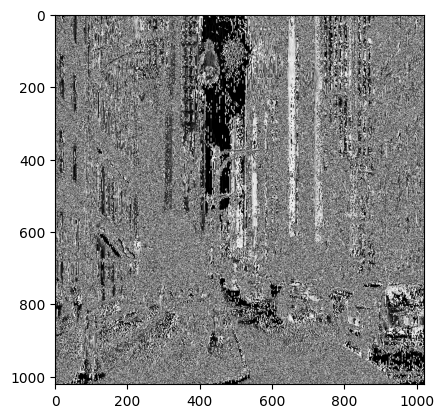

In [37]:
def convolution2d_pooling(image,kernel_shape):
    m, n =kernel_shape
    if (m == n):
        y, x = image.shape
        y = y - m + 1
        x = x - m + 1
        new_image = np.zeros((y,x))
        for i in range(y):
            for j in range(x):
                new_image[i][j] = ((image[i:i+m, j:j+m]).max() )%255
    return new_image

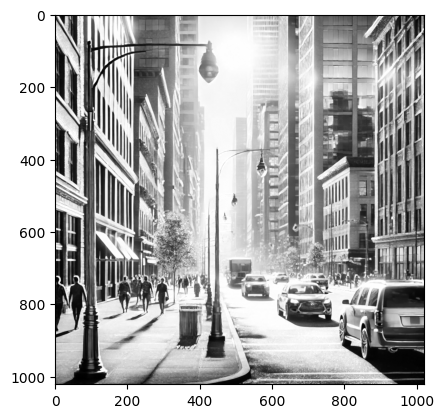

In [39]:
kernel_size=(3,3)
data3=convolution2d_pooling(image,kernel_size)

plt.imshow(data3,cmap='gray')

#2. CNN Model (5 marks)


Implement a Convolutional Neural Network (CNN) using TensorFlow or PyTorch on
the fashion mnist dataset.

(a) Split the dataset into train and test sets. Perform appropriate pre-processing
steps.

(b) Build a basic CNN that satisfies the following criteria and train it:

• the model should use convolutional (conv) layers with ReLU activation.

• you can choose the number of conv layers, kernel size and the number of
filters per layer.

• each conv layers should be followed by a MaxPooling layer with pool size
2x2.

• the extracted features from the conv layers should pass through a fully
connected layer with ReLU activation followed by output layer with softmax
activation function.

(c) Evaluate the performance of the CNN on the test set and report the accuracy,
training time and number of parameters.

In [184]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import fashion_mnist

import keras.layers as layers
data=fashion_mnist
# (x_train, y_train), (x_test, y_test) = data.load_data()
(X_train, y_train), (X_test, y_test) = data.load_data()

assert X_train.shape == (60000, 28, 28)
assert X_test.shape == (10000, 28, 28)
assert  y_train.shape == (60000,)
assert y_test.shape == (10000,)


In [92]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

model = Sequential()

# Layer 1
# Conv 1
model.add(Conv2D(filters=6, kernel_size=(5, 5), strides=1, activation = 'relu', input_shape = (28,28,1)))
# Pooling 1
model.add(MaxPooling2D(pool_size=(2, 2), strides = 2))

# Layer 2
# Conv 2
model.add(Conv2D(filters=16, kernel_size=(5, 5), strides=1, activation='relu'))
# Pooling 2
model.add(MaxPooling2D(pool_size = 2, strides = 2))

# Flatten
model.add(Flatten())

# Layer 3
# Fully connected layer 1
model.add(Dense(units=120, activation='relu'))

#Layer 4
#Fully connected layer 2
model.add(Dense(units=84, activation='relu'))

#Layer 5
#Output Layer
model.add(Dense(units=10, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 24, 24, 6)           │             156 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 12, 12, 6)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 8, 8, 16)            │           2,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 4, 4, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 120)                 │          30,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 84)                  │          10,164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 10)                  │             850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

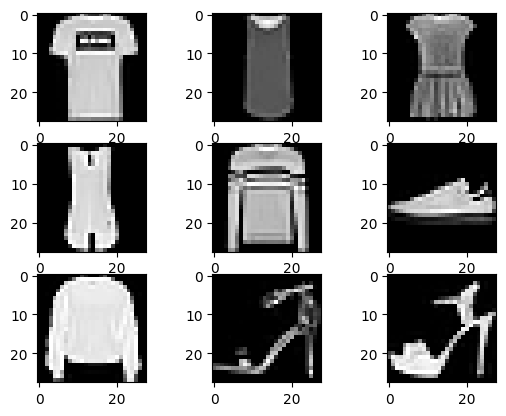

In [90]:

for i in range(1, 10):
    # Create a 3x3 grid and place the
    # image in ith position of grid
    plt.subplot(3, 3, i)
    # Insert ith image with the color map 'grap'
    plt.imshow(train_images[i], cmap=plt.get_cmap('gray'))

# Display the entire plot
plt.show()


In [189]:
from tensorflow.keras.utils import to_categorical

# convert image datatype from integers to floats
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# normalising piel values
X_train = X_train/255.0
X_test = X_test/255.0

# reshape images to add channel dimension
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

# One-hot encoding label
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)


In [94]:
import time
start=time.time()
epochs = 40
batch_size = 512
history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
					steps_per_epoch=X_train.shape[0]//batch_size,
					validation_data=(X_test, y_test),
					validation_steps=X_test.shape[0]//batch_size, verbose = 1)

end=time.time()


Epoch 1/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9095 - loss: 0.2474 - val_accuracy: 0.8938 - val_loss: 0.2972
Epoch 2/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8542 - loss: 0.3244 - val_accuracy: 0.8923 - val_loss: 0.2987
Epoch 3/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9132 - loss: 0.2350 - val_accuracy: 0.8928 - val_loss: 0.3008
Epoch 4/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9271 - loss: 0.2218 - val_accuracy: 0.8945 - val_loss: 0.2926
Epoch 5/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9136 - loss: 0.2367 - val_accuracy: 0.8908 - val_loss: 0.3090
Epoch 6/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8646 - loss: 0.2919 - val_accuracy: 0.8938 - val_loss: 0.3024
Epoch 7/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9126 - loss: 0.2376 - val_accuracy: 0.8885 - val_loss: 0.3142
Epoch 8/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 768us/step - accuracy: 0.9688 - loss: 0.1089 - val_accuracy: 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8964 - loss: 0.3114
 accuracy is 89.710
 the training time is 21.081 


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 24, 24, 6)           │             156 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 12, 12, 6)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 8, 8, 16)            │           2,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 4, 4, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 120)                 │          30,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 84)                  │          10,164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 10)                  │             850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 133,280 (520.63 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 88,854 (347.09 KB)

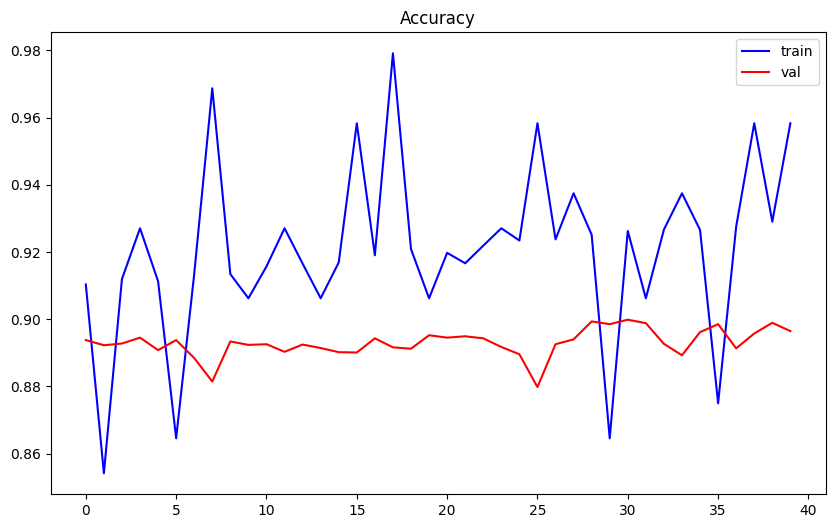

In [101]:

_, acc = model.evaluate(X_test, y_test, verbose = 1)

print(' accuracy is %.3f' % (acc * 100.0))
print(" the training time is %.3f " % (end-start) )
model.summary()

plt.figure(figsize=(10,6))
plt.plot(history.history['accuracy'], color = 'blue', label = 'train')
plt.plot(history.history['val_accuracy'], color = 'red', label = 'val')
plt.legend()
plt.title('Accuracy')
plt.show()


#3. Architecture selection (5 marks)

(a) Experiment with different hyperparameters given below:
• number of conv layers.
• pooling methods.
• kernel size.
• dropout rate.
See how they impact the performance. Plot their accuracy scores.

(b) Plot the learning curve (i.e. accuracy vs. number of epochs) and report classi-
fication metrics for the best model from 3(a).

(c) Compare the performance of best CNN model from 3(a) with a FNN having
similar number of parameters with ReLU activations, trained in similar setup.
Use plots wherever appropriate and report your observations

In [124]:
#increase the no of layers ot the 4
from tensorflow.keras.layers import AveragePooling2D ,Dropout

def model1():
  model = Sequential()
  model.add(Conv2D(filters=6, kernel_size=(3,3), strides=1, activation = 'relu', input_shape = (28,28,1)))
  model.add(AveragePooling2D(pool_size=(2, 2), strides = 2))
  model.add(Conv2D(filters=16, kernel_size=(3,3), strides=1, activation='relu'))
  model.add(AveragePooling2D(pool_size = 2, strides = 2))
  model.add(Conv2D(filters=16, kernel_size=(3,3), strides=1, activation='relu'))
  model.add(AveragePooling2D(pool_size = 2, strides = 2))
  # model.add(Conv2D(filters=16, kernel_size=(3,3), strides=1, activation='relu'))
  # model.add(AveragePooling2D(pool_size = 2, strides = 2))
  model.add(Flatten())
  model.add(Dropout(0.5))
  model.add(Dense(units=120, activation='relu'))
  model.add(Dense(units=84, activation='relu'))
  model.add(Dense(units=10, activation='softmax'))
  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  return model
def model2():
    model = Sequential()
    model.add(Conv2D(filters=6, kernel_size=(3,3), strides=1, activation = 'relu', input_shape = (28,28,1)))
    model.add(MaxPooling2D(pool_size=(2, 2), strides = 2))
    model.add(Conv2D(filters=16, kernel_size=(3,3), strides=1, activation='relu'))
    model.add(MaxPooling2D(pool_size = 2, strides = 2))
    model.add(Conv2D(filters=16, kernel_size=(3,3), strides=1, activation='relu'))
    # model.add(MaxPooling2D(pool_size = 2, strides = 2))
    # model.add(Conv2D(filters=16, kernel_size=(3,3), strides=1, activation='relu'))
    # model.add(MaxPooling2D(pool_size = 2, strides = 2))
    # model.add(Conv2D(filters=16, kernel_size=(3,3), strides=1, activation='relu'))
    # model.add(MaxPooling2D(pool_size = 2, strides = 2))
    model.add(Flatten())
    model.add(Dense(units=120, activation='relu'))
    model.add(Dense(units=84, activation='relu'))
    model.add(Dense(units=10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def model3():
    model = Sequential()
    model.add(Conv2D(filters=6, kernel_size=(5,5), strides=1, activation = 'relu', input_shape = (28,28,1)))
    model.add(AveragePooling2D(pool_size=(2, 2), strides = 2))
    model.add(Conv2D(filters=16, kernel_size=(5,5), strides=1, activation='relu'))
    model.add(AveragePooling2D(pool_size = 2, strides = 2))
    # model.add(Conv2D(filters=16, kernel_size=(5,5), strides=1, activation='relu'))
    # model.add(AveragePooling2D(pool_size = 2, strides = 2))
    # model.add(Conv2D(filters=16, kernel_size=(5,5), strides=1, activation='relu'))
    # model.add(AveragePooling2D(pool_size = 2, strides = 2))
    model.add(Flatten())
    model.add(Dense(units=120, activation='relu'))

    model.add(Dense(units=84, activation='relu'))
    model.add(Dense(units=10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model



In [130]:



epochs = 40
batch_size = 512
print("model  1\n")
model=model1()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history1 = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
					steps_per_epoch=X_train.shape[0]//batch_size,
					validation_data=(X_test, y_test),
					validation_steps=X_test.shape[0]//batch_size, verbose = 1)



model  1

Epoch 1/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.2198 - loss: 2.0158 - val_accuracy: 0.5463 - val_loss: 1.1191
Epoch 2/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 779us/step - accuracy: 0.5417 - loss: 1.2937 - val_accuracy: 0.5454 - val_loss: 1.1254
Epoch 3/40
 11/117 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4779 - loss: 1.2922 

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5145 - loss: 1.2298 - val_accuracy: 0.6265 - val_loss: 0.9893
Epoch 4/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5833 - loss: 1.0950 - val_accuracy: 0.6086 - val_loss: 0.9991
Epoch 5/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5847 - loss: 1.0830 - val_accuracy: 0.6488 - val_loss: 0.9420
Epoch 6/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5625 - loss: 1.0930 - val_accuracy: 0.6352 - val_loss: 0.9494
Epoch 7/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6139 - loss: 1.0046 - val_accuracy: 0.6439 - val_loss: 0.9199
Epoch 8/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step - accuracy: 0.5521 - loss: 1.1721 - val_accuracy: 0.6444 - val_loss: 0.9230
Epoch 9/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6380 - loss: 0.9491 - val_accuracy: 0.6243 - val_loss: 0.9117
Epoch 10/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step - accuracy: 0.6771 - loss: 0.9396 - val_accuracy: 0.6031

In [142]:
print("model  2\n")
model=model2()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history2 = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
					steps_per_epoch=X_train.shape[0]//batch_size,
					validation_data=(X_test, y_test),
					validation_steps=X_test.shape[0]//batch_size, verbose = 1)

model  2



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4609 - loss: 1.5538 - val_accuracy: 0.7451 - val_loss: 0.6603
Epoch 2/40
  1/117 ━━━━━━━━━━━━━━━━━━━━ 2:47 1s/step - accuracy: 0.7917 - loss: 0.5623

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7917 - loss: 0.5623 - val_accuracy: 0.7316 - val_loss: 0.6981
Epoch 3/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7620 - loss: 0.6177 - val_accuracy: 0.7812 - val_loss: 0.5687
Epoch 4/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7708 - loss: 0.5324 - val_accuracy: 0.7810 - val_loss: 0.5682
Epoch 5/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7956 - loss: 0.5361 - val_accuracy: 0.8051 - val_loss: 0.5249
Epoch 6/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7812 - loss: 0.5018 - val_accuracy: 0.8050 - val_loss: 0.5229
Epoch 7/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8210 - loss: 0.4833 - val_accuracy: 0.8240 - val_loss: 0.4805
Epoch 8/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 751us/step - accuracy: 0.8125 - loss: 0.4494 - val_accuracy: 0.8223 - val_loss: 0.4800
Epoch 9/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8329 - loss: 0.4525 - val_accuracy: 0.8296 - v

In [132]:

print("model  3\n")
model=model3()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history3 = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
					steps_per_epoch=X_train.shape[0]//batch_size,
					validation_data=(X_test, y_test),
					validation_steps=X_test.shape[0]//batch_size, verbose = 1)

model  3

Epoch 1/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5251 - loss: 1.4451 - val_accuracy: 0.7271 - val_loss: 0.7029
Epoch 2/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 758us/step - accuracy: 0.7396 - loss: 0.6650 - val_accuracy: 0.7363 - val_loss: 0.6875
Epoch 3/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7555 - loss: 0.6386 - val_accuracy: 0.7635 - val_loss: 0.6273
Epoch 4/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 738us/step - accuracy: 0.7604 - loss: 0.6173 - val_accuracy: 0.7657 - val_loss: 0.6330
Epoch 5/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7920 - loss: 0.5627 - val_accuracy: 0.7964 - val_loss: 0.5581
Epoch 6/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step - accuracy: 0.7083 - loss: 0.6742 - val_accuracy: 0.7943 - val_loss: 0.5621
Epoch 7/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8131 - loss: 0.5093 - val_accuracy: 0.8136 - val_loss: 0.5116
Epoch 8/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step - accuracy: 0.8021 - loss: 0.5533 

In [141]:
print(history1.history['accuracy'][-1])
print(history2.history['accuracy'][-1])
print(history3.history['accuracy'][-1])


0.7291666865348816
0.8958333134651184
0.8854166865348816


In [190]:
from sklearn.metrics import classification_report
_, acc = model.evaluate(X_train, y_train)

print(' accuracy is %.3f' % (acc * 100.0))
print(" the training time is %.3f " % (end-start) )
#

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8960 - loss: 0.2801
 accuracy is 89.560
 the training time is 27.888 


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


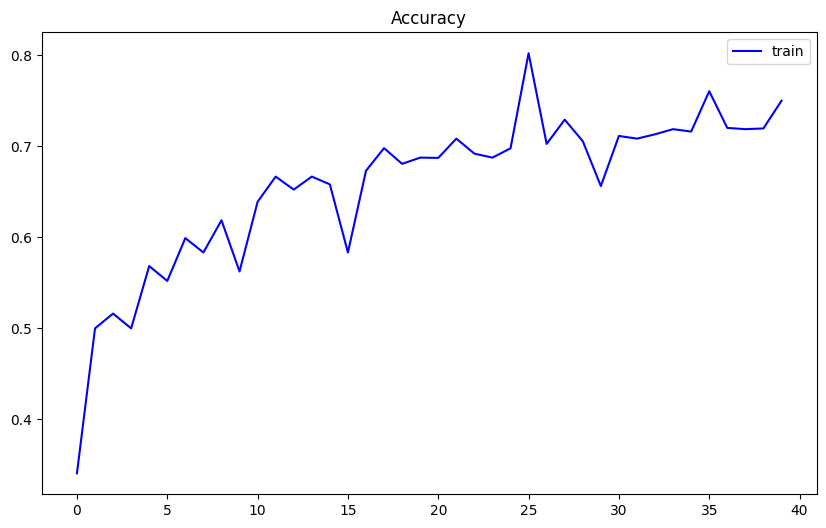

In [194]:
y_pred=model.predict(X_test)
list=[]
for i in range(len(y_pred)):

   list.append(np.argmax(y_pred[i]))

y_pred=list
plt.figure(figsize=(10,6))
plt.plot(history.history['accuracy'], color = 'blue', label = 'train')
  # plt.plot(history.history['val_accuracy'], color = 'red', label = 'val')
plt.legend()
plt.title('Accuracy')
plt.show()


In [195]:
# y_pred=np.argmax(y_pred)

ano=[]
for item in y_test:
  k=0
  for i in range(len(item)):
    if item[i]==1:
      k=i
      ano.append(k)
print(classification_report(ano,y_pred))
model.summary()

              precision    recall  f1-score   support

           0       0.79      0.87      0.83      1000
           1       0.99      0.96      0.98      1000
           2       0.81      0.81      0.81      1000
           3       0.90      0.87      0.89      1000
           4       0.78      0.84      0.81      1000
           5       0.95      0.97      0.96      1000
           6       0.71      0.61      0.66      1000
           7       0.94      0.93      0.94      1000
           8       0.97      0.97      0.97      1000
           9       0.95      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_78 (Conv2D)                   │ (None, 26, 26, 6)           │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (None, 13, 13, 6)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_79 (Conv2D)                   │ (None, 11, 11, 16)          │             880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ (None, 5, 5, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_80 (Conv2D)                   │ (None, 3, 3, 16)            │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_17 (Flatten)                 │ (None, 144)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ (None, 120)                 │          17,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 84)                  │          10,164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 10)                  │             850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 95,024 (371.19 KB)

 Trainable params: 31,674 (123.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 63,350 (247.46 KB)